## Imports

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from scipy.optimize import minimize

from src.models.hull_white import HullWhiteModel
from src.pricing.swaption_pricer import (
    payer_swaption_price,
    receiver_swaption_price,
    forward_swap_rate,
    swap_annuity,
    hull_white_swaption_volatility,
)

# Rates

In [28]:
tickers = {
    "3M": "^IRX",
    "5Y": "^FVX",
    "10Y": "^TNX",
    "30Y": "^TYX",
}

rates_data = yf.download(
    list(tickers.values()),
    start="2020-01-01",
    auto_adjust=True,
    progress=False,
)["Close"]

rates_data = rates_data.rename(columns={v: k for k, v in tickers.items()})
rates_data = rates_data.dropna()

rates_decimal = rates_data / 100
latest_rates = rates_decimal.iloc[-1]

latest_rates

Ticker
5Y     0.04258
3M     0.03588
10Y    0.04595
30Y    0.05128
Name: 2026-05-15 00:00:00, dtype: float64

In [29]:
rate = float(latest_rates["5Y"])
rate

0.042579998970031736

## Hull-White model

In [30]:
mean_reversion = 0.10
volatility = 0.01

hw_model = HullWhiteModel(
    mean_reversion=mean_reversion,
    volatility=volatility,
)

hw_model

HullWhiteModel(mean_reversion=0.1, volatility=0.01)

## Pricing

In [31]:
strike = rate
option_maturity = 1.0
swap_maturity = 6.0
payment_frequency = 1

payer_price = payer_swaption_price(
    strike=strike,
    option_maturity=option_maturity,
    swap_maturity=swap_maturity,
    rate=rate,
    model=hw_model,
    payment_frequency=payment_frequency,
)

payer_price

0.005089695058548911

In [32]:
receiver_price = receiver_swaption_price(
    strike=strike,
    option_maturity=option_maturity,
    swap_maturity=swap_maturity,
    rate=rate,
    model=hw_model,
    payment_frequency=payment_frequency,
)

receiver_price

0.0012050140852727393

In [33]:
fwd_swap_rate = forward_swap_rate(
    rate=rate,
    option_maturity=option_maturity,
    swap_maturity=swap_maturity,
    payment_frequency=payment_frequency,
)

annuity = swap_annuity(
    rate=rate,
    option_maturity=option_maturity,
    swap_maturity=swap_maturity,
    payment_frequency=payment_frequency,
)

effective_vol = hull_white_swaption_volatility(
    option_maturity=option_maturity,
    swap_maturity=swap_maturity,
    model=hw_model,
)

print("Rate:", rate)
print("Forward swap rate:", fwd_swap_rate)
print("Annuity:", annuity)
print("Effective Hull-White volatility:", effective_vol)

Rate: 0.042579998970031736
Forward swap rate: 0.04349953192243706
Annuity: 4.22462399320717
Effective Hull-White volatility: 0.03745915398057633


## Calibration

In [43]:
market_quotes = pd.DataFrame({
    "option_maturity": [1.0, 1.0, 2.0, 2.0, 3.0],
    "swap_maturity": [6.0, 11.0, 7.0, 12.0, 8.0],
    "strike": [rate, rate, rate, rate, rate],
})

true_model = HullWhiteModel(
    mean_reversion=0.15,
    volatility=0.015,
)

market_quotes["market_price"] = market_quotes.apply(
    lambda row: payer_swaption_price(
        strike=row["strike"],
        option_maturity=row["option_maturity"],
        swap_maturity=row["swap_maturity"],
        rate=rate,
        model=true_model,
        payment_frequency=1,
    ),
    axis=1,
)

market_quotes

,option_maturity,swap_maturity,strike,market_price
0,1.0,6.0,0.04258,0.005832
1,1.0,11.0,0.04258,0.013393
2,2.0,7.0,0.04258,0.006602
3,2.0,12.0,0.04258,0.015636
4,3.0,8.0,0.04258,0.006930


In [44]:
def calibration_objective(params):
    mean_reversion, volatility = params

    if mean_reversion <= 0 or volatility <= 0:
        return 1e10

    model = HullWhiteModel(
        mean_reversion=mean_reversion,
        volatility=volatility,
    )

    model_prices = market_quotes.apply(
        lambda row: payer_swaption_price(
            strike=row["strike"],
            option_maturity=row["option_maturity"],
            swap_maturity=row["swap_maturity"],
            rate=rate,
            model=model,
            payment_frequency=1,
        ),
        axis=1,
    )

    error = model_prices - market_quotes["market_price"]

    return float(np.mean(error ** 2))

In [45]:
initial_guess = np.array([0.10, 0.01])

result = minimize(
    calibration_objective,
    initial_guess,
    method="Nelder-Mead",
    options={
        "maxiter": 5000,
        "xatol": 1e-10,
        "fatol": 1e-12,
    },
)

result

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 4.774830979836653e-26
             x: [ 1.500e-01  1.500e-02]
           nit: 78
          nfev: 153
 final_simplex: (array([[ 1.500e-01,  1.500e-02],
                       [ 1.500e-01,  1.500e-02],
                       [ 1.500e-01,  1.500e-02]]), array([ 4.775e-26,  2.519e-25,  2.904e-25]))

In [46]:
calibrated_a, calibrated_sigma = result.x

calibrated_model = HullWhiteModel(
    mean_reversion=calibrated_a,
    volatility=calibrated_sigma,
)

print("Calibrated mean reversion:", calibrated_a)
print("Calibrated volatility:", calibrated_sigma)

Calibrated mean reversion: 0.14999999996774233
Calibrated volatility: 0.014999999998277756


## Market vs Model

In [47]:
market_quotes["model_price"] = market_quotes.apply(
    lambda row: payer_swaption_price(
        strike=row["strike"],
        option_maturity=row["option_maturity"],
        swap_maturity=row["swap_maturity"],
        rate=rate,
        model=calibrated_model,
        payment_frequency=1,
    ),
    axis=1,
)

market_quotes["pricing_error"] = (
    market_quotes["model_price"] - market_quotes["market_price"]
)

market_quotes

,option_maturity,swap_maturity,strike,market_price,model_price,pricing_error
0,1.0,6.0,0.04258,0.005832,0.005832,-9.327782e-14
1,1.0,11.0,0.04258,0.013393,0.013393,2.075493e-13
2,2.0,7.0,0.04258,0.006602,0.006602,-6.430360e-14
3,2.0,12.0,0.04258,0.015636,0.015636,4.273595e-13
4,3.0,8.0,0.04258,0.006930,0.006930,-1.389167e-14


## Plots

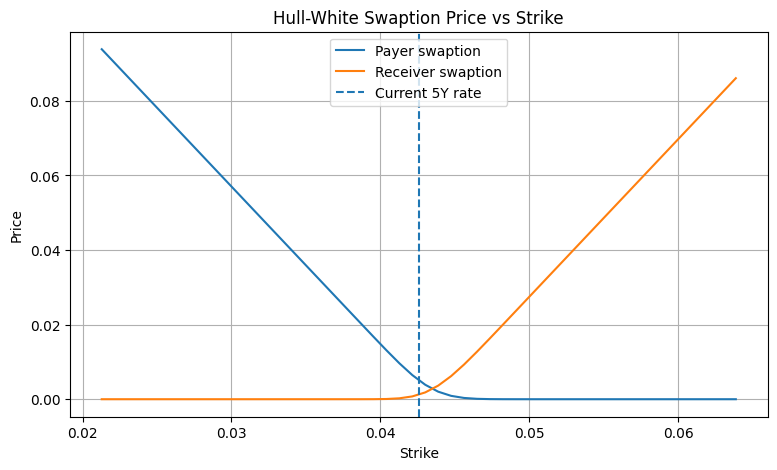

In [34]:
strikes = np.linspace(0.5 * rate, 1.5 * rate, 50)

payer_prices = [
    payer_swaption_price(
        strike=K,
        option_maturity=option_maturity,
        swap_maturity=swap_maturity,
        rate=rate,
        model=hw_model,
        payment_frequency=payment_frequency,
    )
    for K in strikes
]

receiver_prices = [
    receiver_swaption_price(
        strike=K,
        option_maturity=option_maturity,
        swap_maturity=swap_maturity,
        rate=rate,
        model=hw_model,
        payment_frequency=payment_frequency,
    )
    for K in strikes
]

plt.figure(figsize=(9, 5))
plt.plot(strikes, payer_prices, label="Payer swaption")
plt.plot(strikes, receiver_prices, label="Receiver swaption")
plt.axvline(rate, linestyle="--", label="Current 5Y rate")
plt.title("Hull-White Swaption Price vs Strike")
plt.xlabel("Strike")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

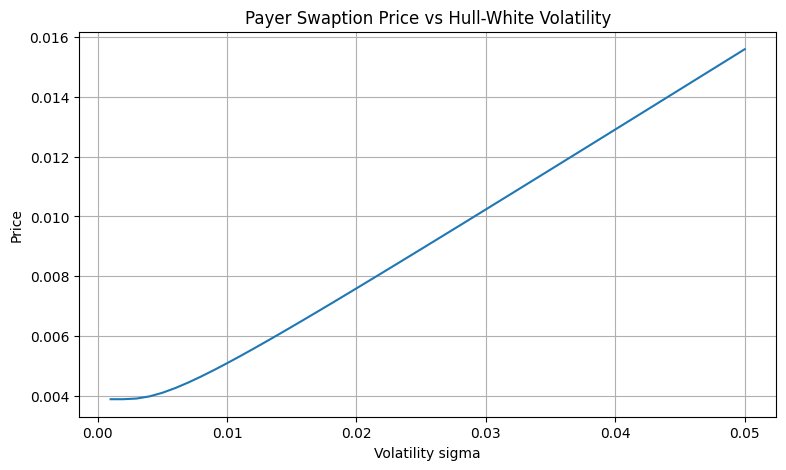

In [35]:
volatilities = np.linspace(0.001, 0.05, 50)

vol_prices = []

for vol in volatilities:
    model_tmp = HullWhiteModel(
        mean_reversion=mean_reversion,
        volatility=vol,
    )

    price_tmp = payer_swaption_price(
        strike=strike,
        option_maturity=option_maturity,
        swap_maturity=swap_maturity,
        rate=rate,
        model=model_tmp,
        payment_frequency=payment_frequency,
    )

    vol_prices.append(price_tmp)

plt.figure(figsize=(9, 5))
plt.plot(volatilities, vol_prices)
plt.title("Payer Swaption Price vs Hull-White Volatility")
plt.xlabel("Volatility sigma")
plt.ylabel("Price")
plt.grid(True)
plt.show()

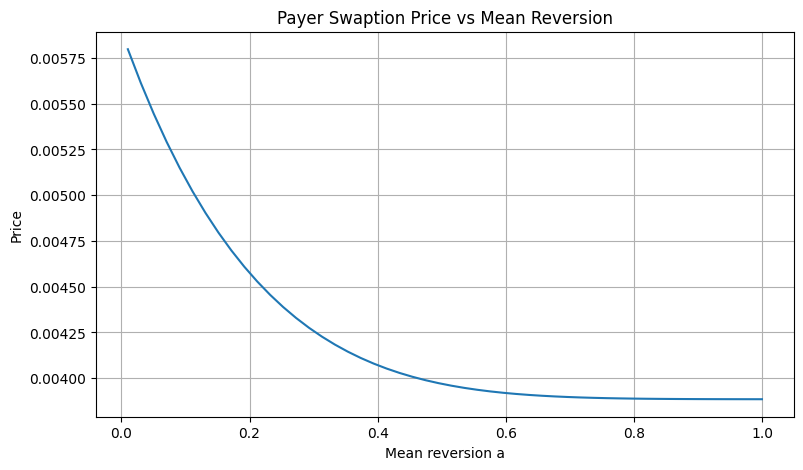

In [36]:
mean_reversions = np.linspace(0.01, 1.0, 50)

mr_prices = []

for mr in mean_reversions:
    model_tmp = HullWhiteModel(
        mean_reversion=mr,
        volatility=volatility,
    )

    price_tmp = payer_swaption_price(
        strike=strike,
        option_maturity=option_maturity,
        swap_maturity=swap_maturity,
        rate=rate,
        model=model_tmp,
        payment_frequency=payment_frequency,
    )

    mr_prices.append(price_tmp)

plt.figure(figsize=(9, 5))
plt.plot(mean_reversions, mr_prices)
plt.title("Payer Swaption Price vs Mean Reversion")
plt.xlabel("Mean reversion a")
plt.ylabel("Price")
plt.grid(True)
plt.show()

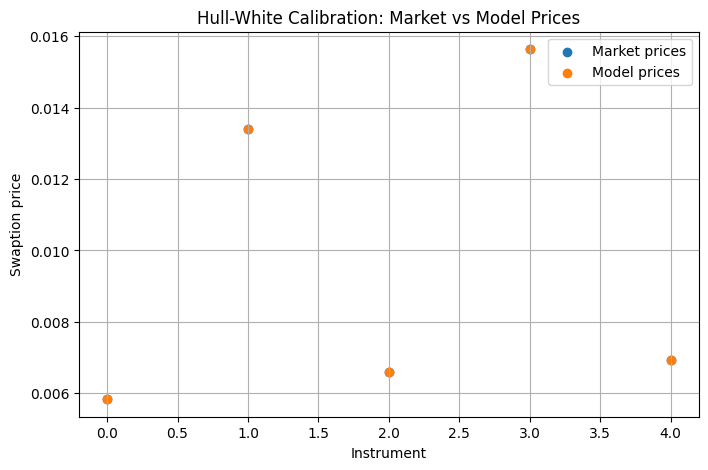

In [42]:
plt.figure(figsize=(8, 5))
plt.scatter(market_quotes.index, market_quotes["market_price"], label="Market prices")
plt.scatter(market_quotes.index, market_quotes["model_price"], label="Model prices")
plt.title("Hull-White Calibration: Market vs Model Prices")
plt.xlabel("Instrument")
plt.ylabel("Swaption price")
plt.legend()
plt.grid(True)
plt.show()

## Market vs Model

### Hull-White Model Conclusion

The Hull-White one-factor model was implemented as a short-rate model with two parameters: mean reversion and volatility. 
Using market interest-rate proxies from Yahoo Finance, a flat-rate approximation was used to price payer and receiver swaptions through an approximate Black-style formula.

The numerical tests behave consistently with financial intuition. Payer swaption prices decrease as the strike increases, while receiver swaption prices increase. The volatility parameter has a strong positive impact on option prices, reflecting the convexity value of optionality. The mean-reversion parameter also affects prices by changing the effective volatility of future short rates.

A synthetic calibration experiment was performed by generating artificial market swaption prices from known Hull-White parameters and recovering them through numerical optimization. This validates the pricing and calibration pipeline.

However, this implementation remains a simplified version of a professional Hull-White framework. The main limitation is the use of a flat yield curve and an approximate swaption volatility formula. A stronger extension would calibrate the model to a full market swaption volatility surface using a bootstrapped zero-coupon curve.